<a href="https://colab.research.google.com/github/LucasSchemes/AVL-Tree/blob/main/Dataset%20Training%20-%20SVM%20and%20RNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Redes Neurais Artificiais - Inteligência Artificial e Computacional

Engenharia de Computação - UFSC

Professor: Dr. Anderson Luiz Fernandes Perez

Alunos: Lucas Saft Schemes e Pedro Antonio Tolardo Magnavita

## Dataset de Classificação
 - Nome: Taiwanese Bankruptcy Prediction
 - Fonte: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction)
 - Objetivo: Prever se uma empresa irá **falir** ou **não falir**
 - Instâncias: 6819
 - Atributos: 95 indicadores financeiros numéricos
 - Target: Status de falência ('1' = Falência, '0' = Não falência)
 - Tipo do problema: Classificação binária

## Análise do dataset

In [ ]:
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [ ]:
taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)

x = taiwanese_bankruptcy_prediction.data.features
y = taiwanese_bankruptcy_prediction.data.targets

In [ ]:
df = pd.concat([x, y], axis=1)
df.head(5)

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,1


In [ ]:
print('Dimensão do DataFrame:')
print(df.shape)

print('\nInformações detalhadas do DataFrame:')
df.info()

print('\nDescrição estatística do DataFrame:')
df.describe()

Dimensão do DataFrame:
(6819, 96)

Informações detalhadas do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1    ROA(A) before interest and % after tax                   6819 non-null   float64
 2    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3    Operating Gross Margin                                   6819 non-null   float64
 4    Realized Sales Gross Margin                              6819 non-null   float64
 5    Operating Profit Rate                                    6819 non-null   float64
 6    Pre-tax net Interest Rate                                6819 non-null   float64
 7    After-tax net Interest Rate     

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Bankrupt?
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000,6819.000000
mean,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,0.781381,...,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578,0.032263
std,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,0.012679,...,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014,0.176710
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,0.781567,...,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477,0.000000
50%,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,0.781635,...,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798,0.000000
75%,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,0.781735,...,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000


* Dataset não apresenta valores ausentes.
* A maioria dos calores parecem normalizados, porém 'Total assets to GNP price' tem valor mínimo de 0.000000e+00 e máximo de 9.820000e+09, sendo necessário padronizar.

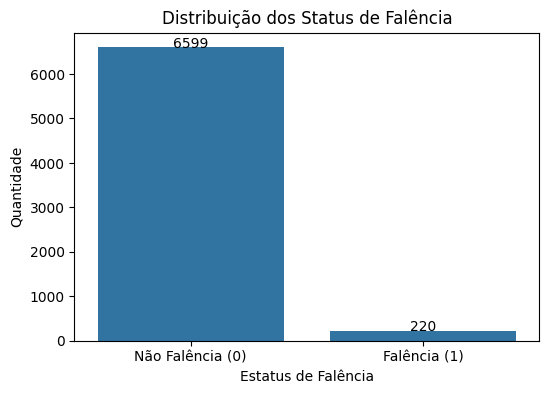

In [ ]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x="Bankrupt?", data=df)

plt.xticks(ticks=[0, 1], labels=['Não Falência (0)', 'Falência (1)'])
plt.title('Distribuição dos Status de Falência')
plt.xlabel('Estatus de Falência')
plt.ylabel('Quantidade')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline')

plt.show()

* Dataset extremamente desbalanceado, exige balanceamento.

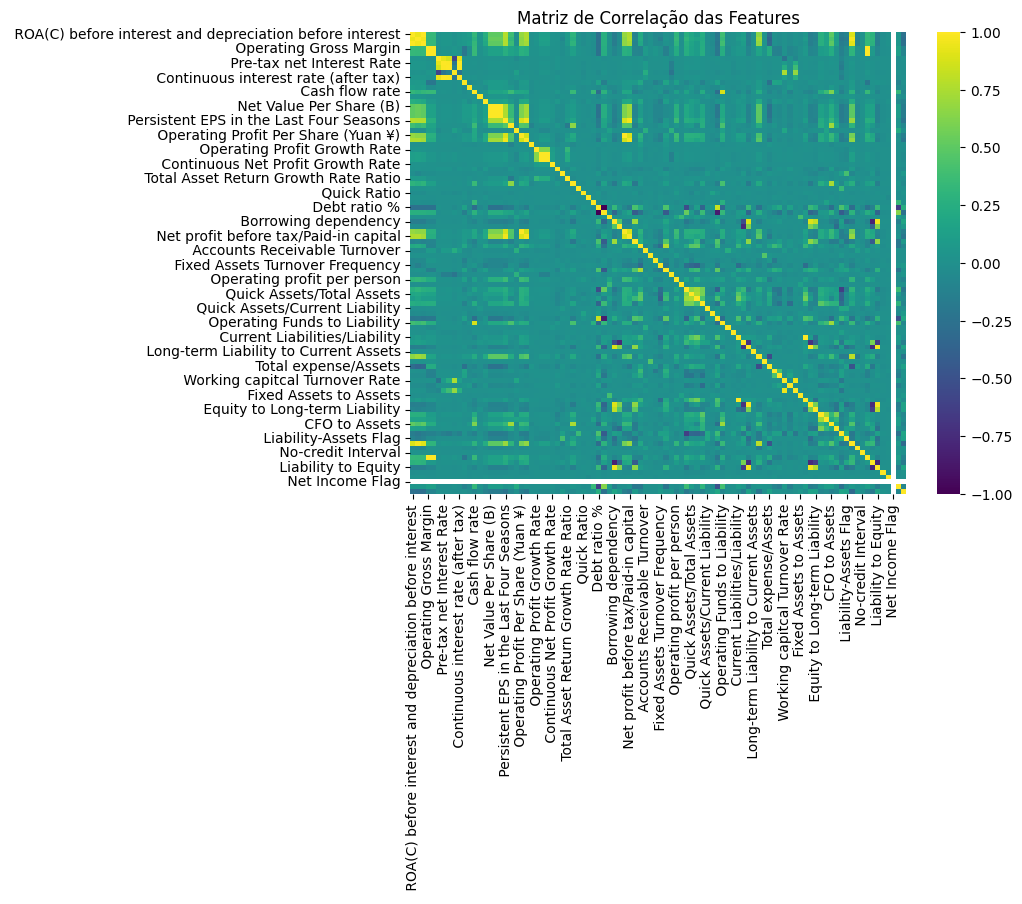

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), cmap='viridis')
plt.title('Matriz de Correlação das Features')
plt.show()

* Não há features com forte correlação, nenhuma remoção será feita.

## Pré-processamento

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
exist_class = np.unique(y_train)

calculate_weights = compute_class_weight(class_weight='balanced', classes=exist_class, y=y_train.values.ravel())

class_weights = {exist_class[0]: calculate_weights[0], exist_class[1]: calculate_weights[1]}

print("Pesos de classe calculados:")
print(class_weights)

Pesos de classe calculados:
{np.int64(0): np.float64(0.5153314618872814), np.int64(1): np.float64(16.806338028169016)}


## Redes Neurais Artificiais

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

NUMERO_NEURONIOS_CAMADA_OCULTA = 75
TAXA_DE_APRENDIZADO = 0.001
NUMERO_DE_EPOCAS = 25
TAMANHO_DO_BATCH = 32

RNA = Sequential()

# Camada de entrada
RNA.add(Input(shape=(x_train_scaled.shape[1],)))

# Camada oculta
RNA.add(Dense(
    units=NUMERO_NEURONIOS_CAMADA_OCULTA,
    activation="relu"
))

# Camada de saída
RNA.add(Dense(
    units=1,
    activation="sigmoid"
))

# Compilação
RNA.compile(
    optimizer=Adam(learning_rate=TAXA_DE_APRENDIZADO),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# Treinamento
historico = RNA.fit(
    x_train_scaled,
    y_train,
    epochs=NUMERO_DE_EPOCAS,
    batch_size=TAMANHO_DO_BATCH,
    class_weight=class_weights,
    validation_split=0.2,
    verbose=1
)

# Teste
perda_teste, acuracia_teste = RNA.evaluate(
    x_test_scaled,
    y_test,
    verbose=0
)

Epoch 1/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.6206 - loss: 0.6037 - val_accuracy: 0.7822 - val_loss: 0.4940
Epoch 2/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7994 - loss: 0.3990 - val_accuracy: 0.8387 - val_loss: 0.4191
Epoch 3/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8435 - loss: 0.3115 - val_accuracy: 0.8827 - val_loss: 0.3318
Epoch 4/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8741 - loss: 0.2799 - val_accuracy: 0.8869 - val_loss: 0.3105
Epoch 5/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8883 - loss: 0.2433 - val_accuracy: 0.8817 - val_loss: 0.3266
Epoch 6/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8930 - loss: 0.2338 - val_accuracy: 0.8838 - val_loss: 0.3074
Epoch 7/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8960 - loss: 0.2258 - val_accuracy: 0.8901 - val_loss: 0.3000
Epoch 8/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8927 - loss: 0.2179 - val_accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = RNA.predict(x_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Não Falência", "Falência"]
))

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Matriz de Confusão:
[[1837  131]
 [  35   43]]

Relatório de Classificação:
              precision    recall  f1-score   support

Não Falência       0.98      0.93      0.96      1968
    Falência       0.25      0.55      0.34        78

    accuracy                           0.92      2046
   macro avg       0.61      0.74      0.65      2046
weighted avg       0.95      0.92      0.93      2046



### Experimentos registrados

#### Experimento 1 – Inicial

**Objetivo:**  
Testar hiperparâmetros

**Configuração:**  
- Camada oculta: 20 neurônios
- Taxa de aprendizado: 0.01  
- Epocas: 100
- Tamanho do Batch: 32

**Resultados:**  
- Recall (Falência): 0.35  
- Precision (Falência): 0.25  
- F1-score (Falência): 0.29  
- 51 falências reais não identificadas

**Observações:**  
O treinamento apresentou sinais claros de overfitting após aproximadamente 25 épocas, com aumento contínuo da perda de validação.

**Conclusão:**  
Os resultados indicam que a configuração inicial da rede não é suficiente para capturar padrões associados à falência, além de apresentar sinais de overfitting.

#### Experimento 2 – Aumento de neurônios e redução de épocas

**Objetivo:**  
Avaliar se o aumento do número de neurônios melhora a detecção de empresas em falência, controlando o sobreajuste.

**Configuração:**  
- Camada oculta: 50 neurônios  
- Taxa de aprendizado: 0.01  
- Épocas: 25  
- Batch size: 32  

**Resultados:**  
- Recall (Falência): 0.54  
- Precision (Falência): 0.20  
- F1-score (Falência): 0.29  
- 42 falências reais identificadas, contra 36 não detectadas  

**Observações:**  
O modelo apresentou maior sensibilidade à classe falência, ao custo de aumento no número de falsos positivos. O overfitting foi parcialmente controlado com a redução do número de épocas.

**Conclusão:**  
O aumento da capacidade da rede resultou em ganho significativo de recall da classe minoritária, mostrando-se mais adequado para o objetivo do problema, embora com perda de precisão.


#### Experimento 3 – Aumento de Neurônios

**Configuração:**
- Camada oculta: 75 neurônios
- Taxa de aprendizado: 0.01
- Épocas: 25
- Batch size: 32

**Resultados (classe Falência):**
- Precision: 0.24
- Recall: 0.53
- F1-score: 0.33
- Falências não detectadas: 37

**Observações:**
O aumento do número de neurônios levou a um crescimento significativo do overfitting, com divergência clara entre perda de treino e validação após poucas épocas. Os ganhos na detecção de falências foram pequenas.

**Conclusão:**
Apenas aumentar a capacidade da rede não é suficiente para melhorar a generalização.


##  SVM (Máquinas de Vetores de Suporte)

- O SVM otimiza os limites de decisão diretamente usando funções de kernel, e seus principais hiperparâmetros são C, gamma e kernel.

## Importações

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np

## Parâmetros - Best SVM



In [ ]:
svm_best = SVC(
    kernel="rbf",
    C=10, # C alto -> rigidez para não errar
    gamma="scale", #influência de UM exemplo
    class_weight="balanced",
    probability=True
)

svm_best.fit(x_train_scaled, y_train.values.ravel()) # ravel -> dados em lista

print("\nModelo SVM treinado com parâmetros fixos.")


Modelo SVM treinado com parâmetros fixos.


## Avaliação

In [ ]:
svm_pred = svm_best.predict(x_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("\nRESULTADOS SVM")
print(f"Acurácia no teste: {svm_accuracy:.4f}\n")

print("Matriz de Confusão (SVM):")
print(confusion_matrix(y_test, svm_pred))

print("\nRelatório de Classificação (SVM):")
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Não Falência", "Falência"]
))



RESULTADOS SVM
Acurácia no teste: 0.9311

Matriz de Confusão (SVM):
[[1874   94]
 [  47   31]]

Relatório de Classificação (SVM):
              precision    recall  f1-score   support

Não Falência       0.98      0.95      0.96      1968
    Falência       0.25      0.40      0.31        78

    accuracy                           0.93      2046
   macro avg       0.61      0.67      0.63      2046
weighted avg       0.95      0.93      0.94      2046



## Curva ROC - Determinação do AUC

AUC-ROC SVM: 0.8588


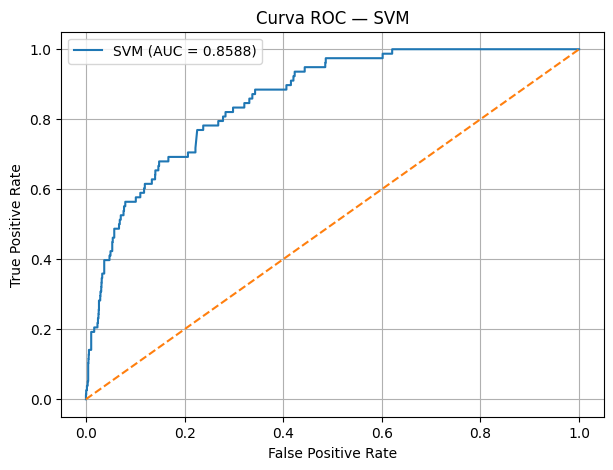

In [ ]:
svm_probs = svm_best.predict_proba(x_test_scaled)[:, 1]
auc_svm = roc_auc_score(y_test, svm_probs)

print(f"AUC-ROC SVM: {auc_svm:.4f}")

fpr, tpr, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_svm:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Curva ROC — SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

##Gráfico de Comparação

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


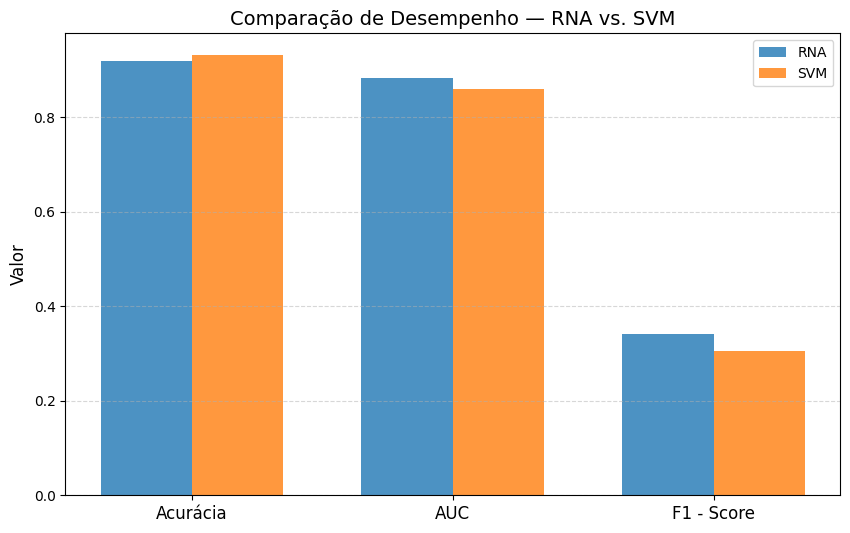

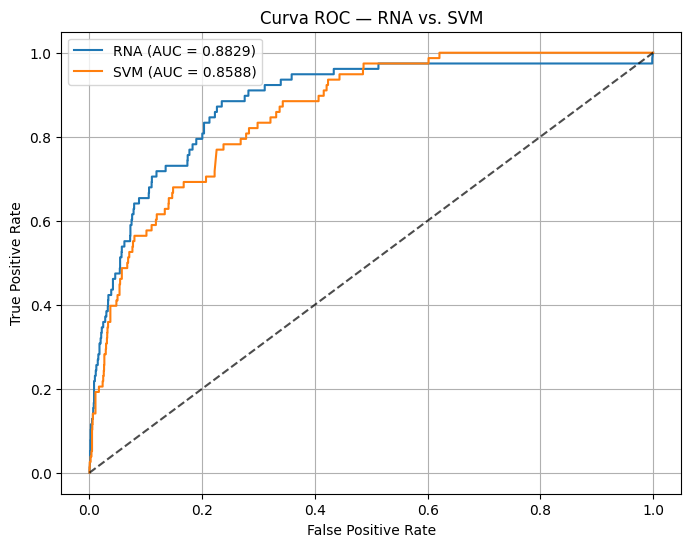

In [ ]:
from sklearn.metrics import f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

rna_probs = RNA.predict(x_test_scaled).ravel()
rna_pred = (rna_probs >= 0.5).astype(int)
rna_f1 = f1_score(y_test, rna_pred)

auc_rna = roc_auc_score(y_test, rna_probs)

svm_probs = svm_best.predict_proba(x_test_scaled)[:, 1]
auc_svm = roc_auc_score(y_test, svm_probs)
svm_f1 = f1_score(y_test, svm_pred)


metricas = ["Acurácia", "AUC", "F1 - Score"]
rna_vals = [acuracia_teste, auc_rna, rna_f1]
svm_vals = [svm_accuracy, auc_svm, svm_f1]

x = np.arange(len(metricas))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, rna_vals, width, label='RNA', alpha=0.8)
plt.bar(x + width/2, svm_vals, width, label='SVM', alpha=0.8)

plt.xticks(x, metricas, fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.title("Comparação de Desempenho — RNA vs. SVM", fontsize=14)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Curva ROC comparando RNA e SVM
fpr_rna, tpr_rna, _ = roc_curve(y_test, rna_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rna, tpr_rna, label=f"RNA (AUC = {auc_rna:.4f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.4f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — RNA vs. SVM")
plt.legend()
plt.grid()
plt.show()

##Conclusão

- Comparação conceitual entre RNA e SVM

| Critério | Redes Neurais Artificiais | SVM |
|---------|---------------------------|-----|
| Base de funcionamento | Neurônios e camadas com aprendizado por gradiente | Maximização da margem entre classes |
| Hiperparâmetros principais | Nº de épocas, taxa de aprendizado, momentum, nº de camadas e neurônios | Kernel, C, gamma |
| Sensibilidade a dados desbalanceados | Alta — precisa de class weights | Alta — precisa de class weights |
| Probabilidade de saída | Nativa via função sigmoid/softmax | Requer `probability=True` |
| Vantagens | Capacidade de aprender padrões complexos com grande volume de dados | Bom desempenho com menos ajustes em datasets tabulares |
| Desvantagens | Requer tunning extenso | Treinamento lento em datasets grandes |

- A partir dos experimentos realizados com o dataset Taiwanese Bankruptcy Prediction, observou-se que tanto o modelo de Redes Neurais Artificiais (RNA) quanto o Support Vector Machine (SVM) foram capazes de aprender padrões relevantes relacionados à previsão de falência empresarial. Entretanto, algumas diferenças importantes ficaram evidentes.

- A RNA, por ser um modelo paramétrico com múltiplos hiperparâmetros (número de épocas, neurônios, camadas intermediárias, taxa de aprendizado etc.), apresenta maior flexibilidade para aprendizagem de relações complexas entre as variáveis. Contudo, essa flexibilidade exige maior tempo de ajustes e sensibilidade a configurações inadequadas, além de demandar uma quantidade maior de dados para atingir seu melhor desempenho

- Por outro lado, o SVM demonstrou bom desempenho mesmo com poucos hiperparâmetros e praticamente sem ajuste fino. Em datasets tabulares e com alta dimensionalidade, como o utilizado neste trabalho (95 atributos), o SVM tende a produzir resultados competitivos com menor esforço de modelagem. A utilização do kernel RBF, aliada ao parâmetro class_weight='balanced', contribuiu para lidar com o forte desbalanceamento do problema. Assim, o SVM tende a ter uma performance mais estável logo na sua primeira execução.